# Proyecto 2ª Evaluación
## Análisis de vuelos por Visibilidad de niebla: Nivel de Luz, Humedad

**Objetivo:** En base el nivel de luz (nubosidad) y la humedad para predecir la baja visibilidad (niebla) y cómo esto afecta la cantidad de vuelos cancelados y el aumento de retrasos por aeropuerto.

**Fuentes:** AirLabs · OpenWeatherMap  
**Tecnologías:** Asyncio · MPI4Py · CuPy/CUDA · Pandas · Matplotlib

In [ ]:
# CELDA 1: Instalación y configuración
!pip install -q mpi4py aiohttp nest_asyncio cupy-cuda12x

import asyncio
import aiohttp
import nest_asyncio
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

#  CuPy / CUDA (GPU )
import cupy as cp
GPU_AVAILABLE = True
print(f"CuPy {cp.__version__} | GPU: {cp.cuda.runtime.getDeviceProperties(0)['name'].decode()}")

# MPI
try:
    from mpi4py import MPI
    comm = MPI.COMM_WORLD
    rank = comm.Get_rank()
    size = comm.Get_size()
    MPI_OK = size > 1
    print(f"MPI inicializado – {size} proceso(s), rank={rank}")
except ImportError:
    rank, size, MPI_OK = 0, 1, False
    print("MPI ejecución solo 1 proceso")

nest_asyncio.apply()

#  Credenciales desde variables de entorno
AIRLABS_KEY     = os.environ.get("AIRLABS_KEY",     "4b6f0f34-27c6-4074-b98f-e3a0985855cb")
OPENWEATHER_KEY = os.environ.get("OPENWEATHER_KEY", "7ed0a6fcf9aeef8a1603c64c88fc8dde")

#Aeropuertos con coordenadas
AEROPUERTOS = {
    "LHR": (51.4700,  -0.4543),   # Londres
    "MEX": (19.4361, -99.0719),   # Ciudad de México
    "SFO": (37.6213, -122.379),   # San Francisco
    "CUU": (28.7028, -105.964),   # Chihuahua
    "JFK": (40.6413,  -73.778),   # Nueva York
    "LAX": (33.9425, -118.408),   # Los Ángeles
    "CDG": (49.0097,    2.548),   # París
}

UMBRAL_NIEBLA_M = 1000  # umbral oficial OACI: visibilidad < 1000 m = niebla

print(f"\n{'='*60}")
print("  Análisis: Nivel de Luz + Humedad → Niebla → Impacto en Vuelos")
print(f"  Aeropuertos: {list(AEROPUERTOS.keys())}")
print(f"{'='*60}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 20.7 MB/s eta 0:00:00
CuPy 14.0.1 | GPU: Tesla T4
MPI inicializado – 1 proceso(s), rank=0

  Análisis: Nivel de Luz + Humedad → Niebla → Impacto en Vuelos
  Aeropuertos: ['LHR', 'MEX', 'SFO', 'CUU', 'JFK', 'LAX', 'CDG']


In [ ]:
# CELDA 2: Consulta concurrente de APIs con Asyncio
#
# Por cada aeropuerto se lanzan EN PARALELO:
#   · OpenWeatherMap → visibilidad, humedad, nubosidad (proxy nivel de luz), punto de rocío
#   · AirLabs        → total vuelos, retrasados, cancelados

async def get_clima(iata, lat, lon):
    """Condiciones ambientales desde OpenWeatherMap."""
    url = (
        f"https://api.openweathermap.org/data/2.5/weather"
        f"?lat={lat}&lon={lon}&appid={OPENWEATHER_KEY}&units=metric"
    )
    async with aiohttp.ClientSession() as s:
        async with s.get(url, timeout=aiohttp.ClientTimeout(total=10)) as r:
            if r.status != 200:
                raise RuntimeError(f"OpenWeather HTTP {r.status} para {iata}")
            d = await r.json()

    temp = d["main"]["temp"]
    hum  = d["main"]["humidity"]

    # Punto de rocío (formula): cuando Temp ≈ Punto de rocío → niebla inminente
    punto_rocio = round(temp - ((100 - hum) / 5.0), 2)

    return {
        "Aeropuerto":    iata,
        "Visibilidad_m": d.get("visibility", 10000),
        "Temperatura_C": temp,
        "Humedad_%":     hum,                                    # variable clave 1
        "Presion_hPa":   d["main"]["pressure"],
        "Nubosidad_%":   d.get("clouds", {}).get("all", 0),      # proxy nivel de luz (0=soleado, 100=nublado)
        "Punto_Rocio_C": punto_rocio,                            # variable clave 2
    }


async def get_vuelos(iata):
    """Estado de vuelos desde AirLabs."""
    url = (
        f"https://airlabs.co/api/v9/schedules"
        f"?dep_iata={iata}&api_key={AIRLABS_KEY}"
    )
    async with aiohttp.ClientSession() as s:
        async with s.get(url, timeout=aiohttp.ClientTimeout(total=10)) as r:
            if r.status != 200:
                raise RuntimeError(f"AirLabs HTTP {r.status} para {iata}")
            vuelos = (await r.json()).get("response", [])

    total = len(vuelos)
    ret   = sum(1 for v in vuelos if v.get("status") == "delayed")
    can   = sum(1 for v in vuelos if v.get("status") == "cancelled")

    return {
        "Aeropuerto":         iata,
        "Total_Vuelos":       total,
        "Retrasados":         ret,
        "Cancelados":         can,
        "Tasa_Retraso_%":     round(ret / total * 100 if total else 0, 2),
        "Tasa_Cancelacion_%": round(can / total * 100 if total else 0, 2),
    }


async def fetch_aeropuerto(iata, lat, lon):
    """Lanza clima y vuelos en paralelo; calcula métricas de niebla."""
    clima, vuelos = await asyncio.gather(
        get_clima(iata, lat, lon),
        get_vuelos(iata),
    )

    vis = clima["Visibilidad_m"]
    hum = clima["Humedad_%"]
    nub = clima["Nubosidad_%"]

    # Factor de niebla: 0 (despejado) → 1 (visibilidad nula)
    factor_niebla = max(0.0, (UMBRAL_NIEBLA_M - vis) / UMBRAL_NIEBLA_M)

    # Indice de riesgo ambiental de niebla:
    #   alta humedad + alta nubosidad (poco nivel de luz) → mayor riesgo
    riesgo_niebla = round((hum / 100.0) * (nub / 100.0) * 100.0, 2)

    if   vis <  100: clasif = "CRITICA"
    elif vis <  500: clasif = "SEVERA"
    elif vis < 1000: clasif = "MODERADA"
    elif vis < 5000: clasif = "LIGERA"
    else:            clasif = "DESPEJADO"

    return {
        **vuelos,
        **{k: v for k, v in clima.items() if k != "Aeropuerto"},
        "Factor_Niebla":        round(factor_niebla, 3),
        "Riesgo_Niebla_%":      riesgo_niebla,
        "Clasificacion_Niebla": clasif,
    }


async def extraer_todos(aeropuertos_locales):
    tareas = [fetch_aeropuerto(a, *AEROPUERTOS[a]) for a in aeropuertos_locales]
    return pd.DataFrame(await asyncio.gather(*tareas))

print("Funciones async definidas")

Funciones async definidas


In [ ]:
# CELDA 3: Pipeline – MPI (distribución de aeropuertos) + CuPy (cálculo en GPU)

async def pipeline_principal():
    lista = list(AEROPUERTOS.keys())

    # ── MPI: distribuir aeropuertos entre procesos ────────────────────────────
    # Con `mpirun -n N` cada rank procesa su subconjunto.
    # En Jupyter (size=1) rank 0 procesa todos.
    if MPI_OK:
        chunks = [list(c) for c in np.array_split(lista, size)] if rank == 0 else None
        locales = comm.scatter(chunks, root=0)
    else:
        locales = lista
    print(f"[Rank {rank}/{size}] procesando: {locales}")

    # ── Asyncio: consultas concurrentes ──────────────────────────────────────
    df_local = await extraer_todos(locales)

    # ── MPI: reunir DataFrames en rank 0 ─────────────────────────────────────
    if MPI_OK:
        todos = comm.gather(df_local, root=0)
        if rank != 0:
            return None
        df = pd.concat(todos, ignore_index=True)
    else:
        df = df_local

    #  CuPy / GPU: calcular índice de impacto de niebla sobre vuelos
    #
    # Fórmula del análisis:
    #   Impacto = (afectados / total) * (humedad/100) * (nubosidad/100) * (1 + factor_niebla) * 100
    #
    #   · humedad/100     → contribución de humedad a la formación de niebla
    #   · nubosidad/100   → reducción de nivel de luz (más nubes = menos luz = más niebla)
    #   · factor_niebla   → severidad actual de visibilidad reducida
    #   · afectados/total → proporción real de vuelos impactados

    cancelados_g = cp.array(df["Cancelados"].values,    dtype=cp.float32)
    retrasados_g = cp.array(df["Retrasados"].values,    dtype=cp.float32)
    total_g      = cp.array(df["Total_Vuelos"].values,  dtype=cp.float32)
    humedad_g    = cp.array(df["Humedad_%"].values,     dtype=cp.float32)
    nubosidad_g  = cp.array(df["Nubosidad_%"].values,   dtype=cp.float32)
    factor_g     = cp.array(df["Factor_Niebla"].values, dtype=cp.float32)

    afectados_g = cancelados_g + retrasados_g

    impacto_g = (
        (afectados_g / (total_g + 1e-6))
        * (humedad_g   / 100.0)
        * (nubosidad_g / 100.0)
        * (1.0 + factor_g)
    ) * 100.0

    df["Afectados_Total"]    = cp.asnumpy(afectados_g).astype(int)
    df["Impacto_Niebla_GPU"] = np.round(cp.asnumpy(impacto_g), 4)

    #  Correlaciones Pearson del análisis
    def nivel_corr(c):
        return "FUERTE" if abs(c) > 0.7 else "MODERADA" if abs(c) > 0.4 else "DÉBIL"

    corr_hum_can  = df["Humedad_%"].corr(df["Cancelados"])
    corr_nub_can  = df["Nubosidad_%"].corr(df["Cancelados"])
    corr_nub_ret  = df["Nubosidad_%"].corr(df["Retrasados"])
    corr_riesgo_t = df["Riesgo_Niebla_%"].corr(df["Tasa_Cancelacion_%"])

    cols = ["Aeropuerto", "Visibilidad_m", "Humedad_%", "Nubosidad_%", "Punto_Rocio_C",
            "Clasificacion_Niebla", "Factor_Niebla", "Riesgo_Niebla_%",
            "Total_Vuelos", "Retrasados", "Cancelados", "Tasa_Retraso_%",
            "Tasa_Cancelacion_%", "Impacto_Niebla_GPU"]

    print(f"\n{'='*85}")
    print("  RESULTADOS – Nivel de Luz + Humedad → Niebla → Impacto en Vuelos")
    print(f"{'='*85}")
    print(df[cols].to_string(index=False))

    print(f"\n  Correlaciones Pearson (análisis central):")
    print(f"    Humedad       ↔ Cancelados       : {corr_hum_can:+.4f}  ({nivel_corr(corr_hum_can)})")
    print(f"    Nubosidad     ↔ Cancelados       : {corr_nub_can:+.4f}  ({nivel_corr(corr_nub_can)})")
    print(f"    Nubosidad     ↔ Retrasados       : {corr_nub_ret:+.4f}  ({nivel_corr(corr_nub_ret)})")
    print(f"    Riesgo_Niebla ↔ Tasa_Cancelacion : {corr_riesgo_t:+.4f}  ({nivel_corr(corr_riesgo_t)})")
    print(f"\n  GPU usado: {'CuPy/CUDA' if GPU_AVAILABLE else 'N/A – se requiere GPU'}")
    print(f"  Vuelos totales: {df['Total_Vuelos'].sum()} | "
          f"Retrasados: {df['Retrasados'].sum()} | "
          f"Cancelados: {df['Cancelados'].sum()}")

    return df

df_resultado = asyncio.run(pipeline_principal())

[Rank 0/1] procesando: ['LHR', 'MEX', 'SFO', 'CUU', 'JFK', 'LAX', 'CDG']

  RESULTADOS – Nivel de Luz + Humedad → Niebla → Impacto en Vuelos
Aeropuerto  Visibilidad_m  Humedad_%  Nubosidad_%  Punto_Rocio_C Clasificacion_Niebla  Factor_Niebla  Riesgo_Niebla_%  Total_Vuelos  Retrasados  Cancelados  Tasa_Retraso_%  Tasa_Cancelacion_%  Impacto_Niebla_GPU
       LHR          10000         77           75           2.92            DESPEJADO            0.0            57.75           100           0           0             0.0                 0.0                0.00
       MEX          10000         67          100          10.08            DESPEJADO            0.0            67.00           100           0           2             0.0                 2.0                1.34
       SFO          10000         85           20           9.19            DESPEJADO            0.0            17.00           100           0           3             0.0                 3.0                0.51
       CUU 

/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


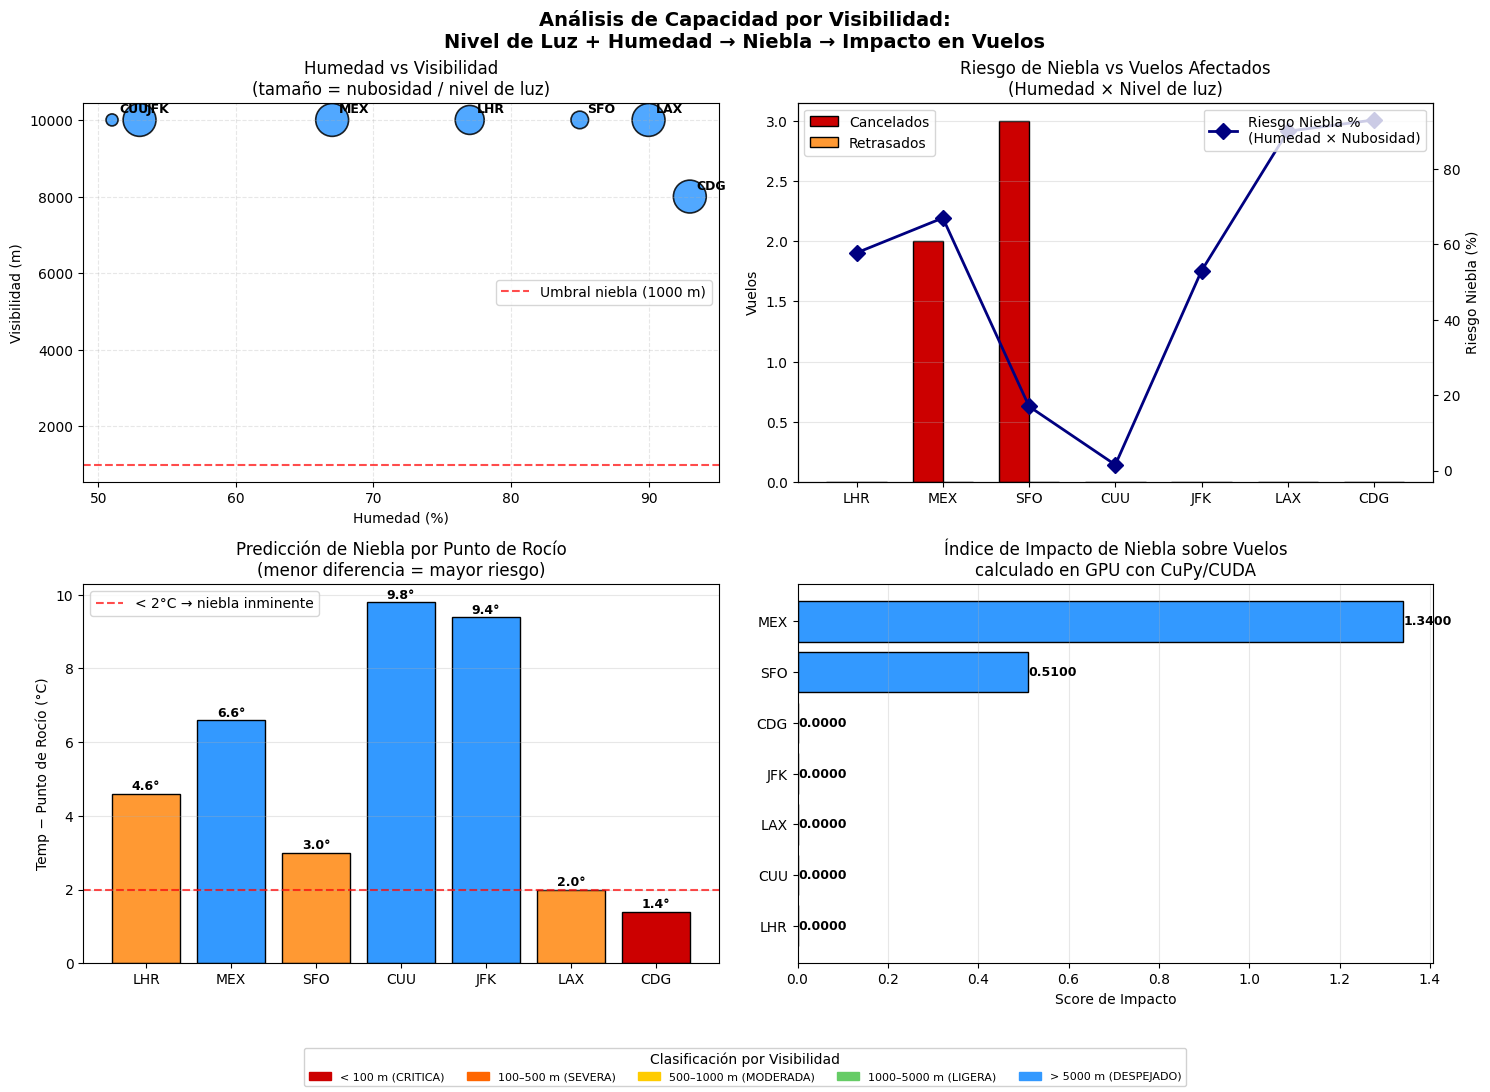

Dashboard guardado: dashboard_niebla_vuelos.png


In [ ]:
# CELDA 4: Visualizacion

def color_vis(v):
    if v <  100: return "#CC0000"
    if v <  500: return "#FF6600"
    if v < 1000: return "#FFCC00"
    if v < 5000: return "#66CC66"
    return "#3399FF"

df = df_resultado
colors = [color_vis(v) for v in df["Visibilidad_m"]]

fig, axes = plt.subplots(2, 2, figsize=(15, 11))
fig.suptitle(
    "Análisis de Capacidad por Visibilidad:\nNivel de Luz + Humedad → Niebla → Impacto en Vuelos",
    fontsize=14, fontweight="bold"
)

#   Subplot 1: Humedad + Nubosidad (nivel de luz) vs Visibilidad       ─
ax = axes[0, 0]
sc = ax.scatter(df["Humedad_%"], df["Visibilidad_m"],
                s=df["Nubosidad_%"] * 5 + 60,   # tamaño = nivel de nubosidad
                c=colors, edgecolors="black", linewidth=1.2, alpha=0.85)
for _, row in df.iterrows():
    ax.annotate(row["Aeropuerto"],
                (row["Humedad_%"], row["Visibilidad_m"]),
                xytext=(5, 5), textcoords="offset points",
                fontsize=9, fontweight="bold")
ax.axhline(y=UMBRAL_NIEBLA_M, color="red", linestyle="--", lw=1.5,
           alpha=0.7, label="Umbral niebla (1000 m)")
ax.set(xlabel="Humedad (%)", ylabel="Visibilidad (m)",
       title="Humedad vs Visibilidad\n(tamaño = nubosidad / nivel de luz)")
ax.legend(); ax.grid(True, alpha=0.3, linestyle="--")

#   Subplot 2: Riesgo de niebla vs Vuelos cancelados y retrasados
ax = axes[0, 1]
x = range(len(df))
width = 0.35
bars1 = ax.bar([i - width/2 for i in x], df["Cancelados"],
               width, color="#CC0000", edgecolor="black", label="Cancelados")
bars2 = ax.bar([i + width/2 for i in x], df["Retrasados"],
               width, color="#FF9933", edgecolor="black", label="Retrasados")
ax2 = ax.twinx()
ax2.plot(list(x), df["Riesgo_Niebla_%"], marker="D", color="#000080",
         lw=2, markersize=8, label="Riesgo Niebla %\n(Humedad × Nubosidad)")
ax.set_xticks(list(x)); ax.set_xticklabels(df["Aeropuerto"])
ax.set(ylabel="Vuelos", title="Riesgo de Niebla vs Vuelos Afectados\n(Humedad × Nivel de luz)")
ax2.set_ylabel("Riesgo Niebla (%)")
ax.legend(loc="upper left"); ax2.legend(loc="upper right")
ax.grid(axis="y", alpha=0.3)

#   Subplot 3: Punto de rocío – predictor de niebla
ax = axes[1, 0]
diferencia_rocio = df["Temperatura_C"] - df["Punto_Rocio_C"]  # cerca de 0 = niebla inminente
bar_colors = ["#CC0000" if d < 2 else "#FF9933" if d < 5 else "#3399FF"
              for d in diferencia_rocio]
bars = ax.bar(df["Aeropuerto"], diferencia_rocio, color=bar_colors, edgecolor="black")
for bar, val in zip(bars, diferencia_rocio):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            f"{val:.1f}°", ha="center", fontsize=9, fontweight="bold")
ax.axhline(y=2, color="red", linestyle="--", lw=1.5, alpha=0.7,
           label="< 2°C → niebla inminente")
ax.set(ylabel="Temp − Punto de Rocío (°C)",
       title="Predicción de Niebla por Punto de Rocío\n(menor diferencia = mayor riesgo)")
ax.legend(); ax.grid(axis="y", alpha=0.3)

#   Subplot 4: Índice de impacto calculado en GPU (CuPy)           ─
ax = axes[1, 1]
sorted_df = df.sort_values("Impacto_Niebla_GPU", ascending=True)
bar_colors2 = [color_vis(v) for v in sorted_df["Visibilidad_m"]]
bars = ax.barh(sorted_df["Aeropuerto"], sorted_df["Impacto_Niebla_GPU"],
               color=bar_colors2, edgecolor="black")
for bar, val in zip(bars, sorted_df["Impacto_Niebla_GPU"]):
    ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
            f"{val:.4f}", va="center", fontsize=9, fontweight="bold")
ax.set(xlabel="Score de Impacto",
       title="Índice de Impacto de Niebla sobre Vuelos\ncalculado en GPU con CuPy/CUDA")
ax.grid(axis="x", alpha=0.3)

# Leyenda de colores de visibilidad
from matplotlib.patches import Patch
leyenda_vis = [
    Patch(color="#CC0000", label="< 100 m (CRITICA)"),
    Patch(color="#FF6600", label="100–500 m (SEVERA)"),
    Patch(color="#FFCC00", label="500–1000 m (MODERADA)"),
    Patch(color="#66CC66", label="1000–5000 m (LIGERA)"),
    Patch(color="#3399FF", label="> 5000 m (DESPEJADO)"),
]
fig.legend(handles=leyenda_vis, loc="lower center", ncol=5,
           fontsize=8, title="Clasificación por Visibilidad", framealpha=0.9)

plt.tight_layout(rect=[0, 0.06, 1, 1])
plt.savefig("dashboard_niebla_vuelos.png", dpi=150, bbox_inches="tight")
plt.show()
print("Dashboard guardado: dashboard_niebla_vuelos.png")

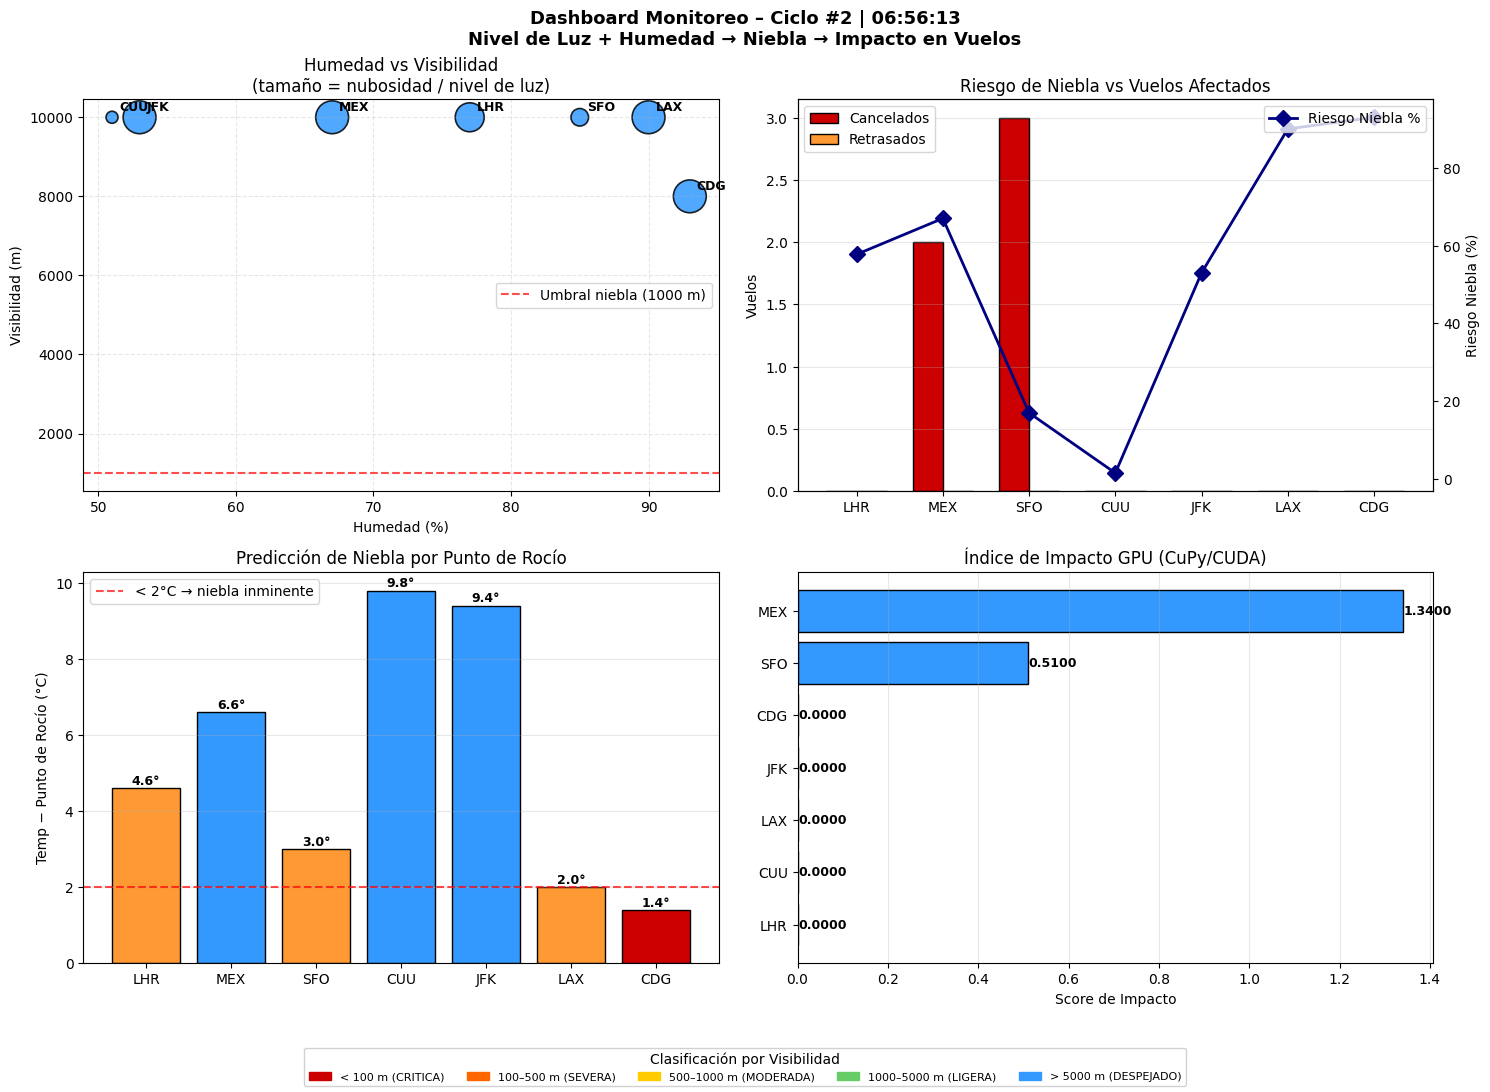


  Próxima actualización en 30 segundos... (Kernel → Interrupt para detener)


KeyboardInterrupt: 

In [ ]:
# CELDA 5: Monitoreo continuo con actualizacion cada 30 segundos
#
# Cada ciclo lo q hace es q:
#   Consulta Asyncio a OpenWeatherMap + AirLabs
#   Distribución entre procesos con MPI
#   Calculo con GPU (CuPy)
#   Regenera el dashboard
#

from IPython.display import clear_output

INTERVALO_SEG = 30   # segundos entre ciclos

async def monitoreo_continuo():
    ciclo = 1
    while True:
        print(f"\n{'='*60}")
        print(f"  CICLO #{ciclo}  |  {pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S')}")
        print(f"{'='*60}")

        #   Ejecutar pipeline completo
        global df_resultado
        df_resultado = await pipeline_principal()

        if df_resultado is None:
            # rank != 0 en modo MPI, nada que hacer aquí
            break

        #   Regenerar dashboard                      ─
        clear_output(wait=True)

        df = df_resultado
        colors = [color_vis(v) for v in df["Visibilidad_m"]]

        fig, axes = plt.subplots(2, 2, figsize=(15, 11))
        fig.suptitle(
            f"Dashboard Monitoreo – Ciclo #{ciclo} | "
            f"{pd.Timestamp.now().strftime('%H:%M:%S')}\n"
            "Nivel de Luz + Humedad → Niebla → Impacto en Vuelos",
            fontsize=13, fontweight="bold"
        )

        # Subplot 1: Humedad vs Visibilidad
        ax = axes[0, 0]
        ax.scatter(df["Humedad_%"], df["Visibilidad_m"],
                   s=df["Nubosidad_%"] * 5 + 60,
                   c=colors, edgecolors="black", linewidth=1.2, alpha=0.85)
        for _, row in df.iterrows():
            ax.annotate(row["Aeropuerto"],
                        (row["Humedad_%"], row["Visibilidad_m"]),
                        xytext=(5, 5), textcoords="offset points",
                        fontsize=9, fontweight="bold")
        ax.axhline(y=UMBRAL_NIEBLA_M, color="red", linestyle="--",
                   lw=1.5, alpha=0.7, label="Umbral niebla (1000 m)")
        ax.set(xlabel="Humedad (%)", ylabel="Visibilidad (m)",
               title="Humedad vs Visibilidad\n(tamaño = nubosidad / nivel de luz)")
        ax.legend(); ax.grid(True, alpha=0.3, linestyle="--")

        # Subplot 2: Riesgo niebla vs vuelos afectados
        ax = axes[0, 1]
        x = range(len(df))
        width = 0.35
        ax.bar([i - width/2 for i in x], df["Cancelados"],
               width, color="#CC0000", edgecolor="black", label="Cancelados")
        ax.bar([i + width/2 for i in x], df["Retrasados"],
               width, color="#FF9933", edgecolor="black", label="Retrasados")
        ax2 = ax.twinx()
        ax2.plot(list(x), df["Riesgo_Niebla_%"], marker="D", color="#000080",
                 lw=2, markersize=8, label="Riesgo Niebla %")
        ax.set_xticks(list(x)); ax.set_xticklabels(df["Aeropuerto"])
        ax.set(ylabel="Vuelos", title="Riesgo de Niebla vs Vuelos Afectados")
        ax2.set_ylabel("Riesgo Niebla (%)")
        ax.legend(loc="upper left"); ax2.legend(loc="upper right")
        ax.grid(axis="y", alpha=0.3)

        # Subplot 3: Punto de rocío
        ax = axes[1, 0]
        diferencia_rocio = df["Temperatura_C"] - df["Punto_Rocio_C"]
        bar_colors = ["#CC0000" if d < 2 else "#FF9933" if d < 5 else "#3399FF"
                      for d in diferencia_rocio]
        bars = ax.bar(df["Aeropuerto"], diferencia_rocio,
                      color=bar_colors, edgecolor="black")
        for bar, val in zip(bars, diferencia_rocio):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                    f"{val:.1f}°", ha="center", fontsize=9, fontweight="bold")
        ax.axhline(y=2, color="red", linestyle="--", lw=1.5, alpha=0.7,
                   label="< 2°C → niebla inminente")
        ax.set(ylabel="Temp − Punto de Rocío (°C)",
               title="Prediccion de Niebla por Punto de Rocío")
        ax.legend(); ax.grid(axis="y", alpha=0.3)

        # Subplot 4: Índice GPU
        ax = axes[1, 1]
        sorted_df = df.sort_values("Impacto_Niebla_GPU", ascending=True)
        bar_colors2 = [color_vis(v) for v in sorted_df["Visibilidad_m"]]
        bars = ax.barh(sorted_df["Aeropuerto"], sorted_df["Impacto_Niebla_GPU"],
                       color=bar_colors2, edgecolor="black")
        for bar, val in zip(bars, sorted_df["Impacto_Niebla_GPU"]):
            ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
                    f"{val:.4f}", va="center", fontsize=9, fontweight="bold")
        ax.set(xlabel="Score de Impacto",
               title="Índice de Impacto GPU (CuPy/CUDA)")
        ax.grid(axis="x", alpha=0.3)

        from matplotlib.patches import Patch
        leyenda_vis = [
            Patch(color="#CC0000", label="< 100 m (CRITICA)"),
            Patch(color="#FF6600", label="100–500 m (SEVERA)"),
            Patch(color="#FFCC00", label="500–1000 m (MODERADA)"),
            Patch(color="#66CC66", label="1000–5000 m (LIGERA)"),
            Patch(color="#3399FF", label="> 5000 m (DESPEJADO)"),
        ]
        fig.legend(handles=leyenda_vis, loc="lower center", ncol=5,
                   fontsize=8, title="Clasificacion por Visibilidad", framealpha=0.9)

        plt.tight_layout(rect=[0, 0.06, 1, 1])
        plt.savefig(f"ciclo_{ciclo:03d}.png", dpi=130, bbox_inches="tight")
        plt.show()

        print(f"\n  Proxima actualizacion en {INTERVALO_SEG} segundos")
        await asyncio.sleep(INTERVALO_SEG)
        ciclo += 1

# Iniciar monitoreo
asyncio.run(monitoreo_continuo())